# Financial Forecasting Models and Evaluation

## 1. Introduction
This notebook builds a production-grade forecasting pipeline for financial time series data. The objective is to predict **returns** derived from the close price using a time-based train/test split, multiple models, and rigorous evaluation. Returns are chosen to stabilize the scale and focus the models on relative changes rather than raw price levels.

## 2. Data Loading & Validation

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("data/raw/market_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected data file not found: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,TimeStamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,OpenPrice,ClosePrice,HighPrice,LowPrice,Volume,Return
0,2015-01-05 09:00:00,C,2376.0,1632.0,2962.0,7625.0,1.705367e+09,11471648.0,23749.63,2376.042539,2372.565770,2374.304155,2376.0,2377.0,2380.0,2369.0,1632.0,0.000000
1,2015-01-05 09:01:00,C,2380.0,2238.0,3187.0,6045.0,2.613201e+09,8258962.0,23756.60,2378.624412,2376.854425,2377.739418,2376.0,2377.0,2380.0,2369.0,606.0,0.001684
2,2015-01-05 09:02:00,C,2380.0,2990.0,9159.0,9063.0,3.707500e+09,8695624.0,23766.27,2380.027405,2379.009599,2379.518502,2376.0,2377.0,2380.0,2369.0,752.0,0.000000
3,2015-01-05 09:03:00,C,2379.0,3270.0,3307.0,8496.0,4.134458e+09,7994510.0,23769.14,2380.707288,2379.025424,2379.866356,2376.0,2377.0,2380.0,2369.0,280.0,-0.000420
4,2015-01-05 09:04:00,C,2378.0,4480.0,4862.0,8416.0,4.525012e+09,7292090.0,23775.69,2380.634101,2379.062500,2379.848301,2376.0,2377.0,2380.0,2369.0,1210.0,-0.000420


In [2]:
print("Shape:", df_raw.shape)
df_raw.info()

Shape: (459688, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459688 entries, 0 to 459687
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   TimeStamp     459688 non-null  object 
 1   ID            459676 non-null  object 
 2   LastPrice     459676 non-null  float64
 3   TotalVolume   459676 non-null  float64
 4   AskVolume     459688 non-null  float64
 5   BidVolume     459688 non-null  float64
 6   Turnover      459688 non-null  float64
 7   OpenInterest  459676 non-null  float64
 8   VWAP          459688 non-null  float64
 9   AskPrice      459688 non-null  float64
 10  BidPrice      459688 non-null  float64
 11  AveragePrice  459688 non-null  float64
 12  OpenPrice     459339 non-null  float64
 13  ClosePrice    459688 non-null  float64
 14  HighPrice     459688 non-null  float64
 15  LowPrice      459688 non-null  float64
 16  Volume        459676 non-null  float64
 17  Return        459688 non-nul

In [3]:
# Standardize column names if needed
df_raw.columns = [c.strip() for c in df_raw.columns]

rename_map = {
    "TimeStamp": "timestamp",
    "OpenPrice": "open",
    "HighPrice": "high",
    "LowPrice": "low",
    "ClosePrice": "close",
    "Volume": "volume",
}

# Case-insensitive rename
rename_map_ci = {k.lower(): v for k, v in rename_map.items()}
df_raw = df_raw.rename(
    columns={c: rename_map_ci[c.lower()] for c in df_raw.columns if c.lower() in rename_map_ci}
)

required_cols = ["timestamp", "open", "high", "low", "close", "volume"]
missing_required = [c for c in required_cols if c not in df_raw.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Parse timestamps and sort
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], errors="coerce", utc=True)
df_raw = df_raw.dropna(subset=["timestamp"]).sort_values("timestamp")

print("Missing values by column:\n", df_raw.isna().sum())
df_raw.describe(include="all")

Missing values by column:
 timestamp         0
ID               12
LastPrice        12
TotalVolume      12
AskVolume         0
BidVolume         0
Turnover          0
OpenInterest     12
VWAP              0
AskPrice          0
BidPrice          0
AveragePrice      0
open            349
close             0
high              0
low               0
volume           12
Return            0
dtype: int64


,timestamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,open,close,high,low,volume,Return
count,459688,459676,459676.000000,4.596760e+05,4.596880e+05,4.596880e+05,4.596880e+05,4.596760e+05,459688.000000,459688.000000,459688.000000,459688.000000,459339.000000,459688.000000,459688.000000,459688.000000,459676.000000,4.596880e+05
unique,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,459676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2018-11-05 19:07:56.615008768+00:00,NaN,2056.717760,2.995661e+05,7.322517e+04,7.382437e+04,5.128060e+11,8.352072e+07,20466.410095,2048.647456,2048.370153,2048.508805,2057.087378,2056.678423,2065.244166,2048.250107,2206.571633,-2.742162e-07
min,2015-01-05 09:00:00+00:00,NaN,1382.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.413780e+05,0.000000,0.000000,0.000000,0.000000,1389.000000,1390.000000,1399.000000,1382.000000,-242528.000000,-2.018349e-02
25%,2017-02-06 09:09:45+00:00,NaN,1775.000000,1.165480e+05,3.160600e+04,3.117600e+04,1.388772e+11,4.658133e+07,17698.927500,1771.000000,1770.000000,1770.500000,1775.000000,1777.000000,1781.000000,1768.000000,250.750000,-3.888025e-04
50%,2019-02-28 09:19:30+00:00,NaN,1916.000000,2.382155e+05,5.782200e+04,5.743000e+04,3.344852e+11,7.079570e+07,19152.470000,1916.000000,1915.000000,1915.500000,1917.000000,1916.000000,1920.000000,1911.000000,841.000000,0.000000e+00
75%,2020-08-20 10:38:15+00:00,NaN,2483.000000,4.045980e+05,9.747125e+04,9.681500e+04,7.126904e+11,1.064313e+08,24817.922500,2482.404446,2481.190293,2481.809205,2483.000000,2482.000000,2490.000000,2475.000000,2264.000000,3.883495e-04
max,2021-12-31 15:00:00+00:00,NaN,2913.000000,3.723882e+06,1.637217e+06,5.483269e+06,7.090729e+12,4.271132e+08,28947.600000,2912.462951,2911.034840,2911.677458,2909.000000,2902.000000,2913.000000,2882.000000,720338.000000,9.852217e-03


## 3. Feature Engineering (if not already done)

In [4]:
def ensure_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure core forecasting features are present. If missing, create them.
    Features are based on historical close values and returns.
    """
    df = df.copy()

    if "returns" not in df.columns:
        df["returns"] = df["close"].pct_change()
    if "ma7" not in df.columns:
        df["ma7"] = df["close"].rolling(window=7).mean()
    if "ma30" not in df.columns:
        df["ma30"] = df["close"].rolling(window=30).mean()
    if "volatility_30" not in df.columns:
        df["volatility_30"] = df["returns"].rolling(window=30).std()

    for lag in [1, 2, 3]:
        col = f"lag_{lag}"
        if col not in df.columns:
            df[col] = df["returns"].shift(lag)

    return df


df_feat = ensure_features(df_raw)
df_feat.head()

,timestamp,ID,LastPrice,TotalVolume,AskVolume,BidVolume,Turnover,OpenInterest,VWAP,AskPrice,BidPrice,AveragePrice,open,close,high,low,volume,Return,returns,ma7,ma30,volatility_30,lag_1,lag_2,lag_3
0,2015-01-05 09:00:00+00:00,C,2376.0,1632.0,2962.0,7625.0,1.705367e+09,11471648.0,23749.63,2376.042539,2372.565770,2374.304155,2376.0,2377.0,2380.0,2369.0,1632.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05 09:01:00+00:00,C,2380.0,2238.0,3187.0,6045.0,2.613201e+09,8258962.0,23756.60,2378.624412,2376.854425,2377.739418,2376.0,2377.0,2380.0,2369.0,606.0,0.001684,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-05 09:02:00+00:00,C,2380.0,2990.0,9159.0,9063.0,3.707500e+09,8695624.0,23766.27,2380.027405,2379.009599,2379.518502,2376.0,2377.0,2380.0,2369.0,752.0,0.000000,0.0,NaN,NaN,NaN,0.0,NaN,NaN
3,2015-01-05 09:03:00+00:00,C,2379.0,3270.0,3307.0,8496.0,4.134458e+09,7994510.0,23769.14,2380.707288,2379.025424,2379.866356,2376.0,2377.0,2380.0,2369.0,280.0,-0.000420,0.0,NaN,NaN,NaN,0.0,0.0,NaN
4,2015-01-05 09:04:00+00:00,C,2378.0,4480.0,4862.0,8416.0,4.525012e+09,7292090.0,23775.69,2380.634101,2379.062500,2379.848301,2376.0,2377.0,2380.0,2369.0,1210.0,-0.000420,0.0,NaN,NaN,NaN,0.0,0.0,0.0


## 4. Train/Test Split (Time-Based)

In [5]:
# Avoid look-ahead bias: shift contemporaneous features by 1 step
feature_cols = ["returns", "ma7", "ma30", "volatility_30", "volume", "lag_1", "lag_2", "lag_3"]
shift_cols = ["returns", "ma7", "ma30", "volatility_30", "volume"]

df_model = df_feat.copy()
df_model[shift_cols] = df_model[shift_cols].shift(1)

# Target: returns
target_col = "returns"

# Drop rows with NaNs introduced by rolling windows and shifts
df_model = df_model.dropna().reset_index(drop=True)

X = df_model[feature_cols]
y = df_model[target_col]

split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (367446, 8)
Test size: (91862, 8)


## 5. Baseline Model (Naive)

In [6]:
def rmse(y_true, y_pred) -> float:
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate(y_true, y_pred) -> dict:
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
    }


def naive_previous_value_forecast(y_train: pd.Series, y_test: pd.Series) -> pd.Series:
    """
    Naive forecast: prediction = previous observed value.
    The first prediction in the test set uses the last train value.
    """
    y_pred = y_test.shift(1)
    y_pred.iloc[0] = y_train.iloc[-1]
    return y_pred


y_pred_naive = naive_previous_value_forecast(y_train, y_test)
baseline_metrics = evaluate(y_test, y_pred_naive)
baseline_metrics

{'rmse': np.float64(0.0007045916521514478), 'mae': 5.580148767841787e-05}

## 6. Machine Learning Models

In [7]:
# Model 1: Linear Regression (with scaling)
linreg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
linreg_model.fit(X_train, y_train)
y_pred_linreg = linreg_model.predict(X_test)
linreg_metrics = evaluate(y_test, y_pred_linreg)

linreg_metrics

{'rmse': np.float64(5.661196824103631e-16), 'mae': 3.928272612051313e-17}

In [8]:
# Model 2: Random Forest
from joblib import parallel_backend

MAX_TRAIN_SAMPLES = 100_000
X_train_rf = X_train
Y_train_rf = y_train
if len(X_train_rf) > MAX_TRAIN_SAMPLES:
    X_train_rf = X_train_rf.iloc[-MAX_TRAIN_SAMPLES:]
    Y_train_rf = Y_train_rf.iloc[-MAX_TRAIN_SAMPLES:]

rf_model = RandomForestRegressor(
    n_estimators=120,
    max_depth=12,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=1,
)

# Force sequential backend to avoid restricted thread pool primitives
with parallel_backend("sequential"):
    rf_model.fit(X_train_rf, Y_train_rf)

y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate(y_test, y_pred_rf)

rf_metrics

{'rmse': np.float64(2.5916329310245076e-05), 'mae': 5.619751354788304e-07}

### Optional: XGBoost (if available)

In [9]:
xgb_metrics = None
xgb_model = None

try:
    from xgboost import XGBRegressor

    MAX_TRAIN_SAMPLES = 100_000
    X_train_xgb = X_train
    Y_train_xgb = y_train
    if len(X_train_xgb) > MAX_TRAIN_SAMPLES:
        X_train_xgb = X_train_xgb.iloc[-MAX_TRAIN_SAMPLES:]
        Y_train_xgb = Y_train_xgb.iloc[-MAX_TRAIN_SAMPLES:]

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
    )
    xgb_model.fit(X_train_xgb, Y_train_xgb)
    y_pred_xgb = xgb_model.predict(X_test)
    xgb_metrics = evaluate(y_test, y_pred_xgb)
except Exception as exc:
    print("XGBoost not available or failed to run:", exc)

xgb_metrics

{'rmse': np.float64(0.00023752830642504417), 'mae': 1.6182549052312715e-05}

## 7. (Optional Advanced) Deep Learning Model (LSTM)
This section is optional and will only run if TensorFlow is available.

In [10]:
RUN_LSTM = False

lstm_metrics = None

if RUN_LSTM:
    try:
        import tensorflow as tf
        from tensorflow.keras import layers, models

        # Prepare sequences
        seq_len = 20
        feature_array = X.values
        target_array = y.values

        X_seq, y_seq = [], []
        for i in range(seq_len, len(feature_array)):
            X_seq.append(feature_array[i - seq_len : i])
            y_seq.append(target_array[i])

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        split_seq = int(len(X_seq) * 0.8)
        X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
        y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

        # LSTM model
        lstm = models.Sequential([
            layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
            layers.LSTM(64, return_sequences=False),
            layers.Dense(1),
        ])

        lstm.compile(optimizer="adam", loss="mse")
        lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, verbose=0)

        y_pred_lstm = lstm.predict(X_test_seq).flatten()
        lstm_metrics = evaluate(pd.Series(y_test_seq), pd.Series(y_pred_lstm))

    except Exception as exc:
        print("LSTM not available or failed to run:", exc)

lstm_metrics

## 8. Model Comparison

In [11]:
results = [
    {"model": "Naive", "rmse": baseline_metrics["rmse"], "mae": baseline_metrics["mae"], "object": None},
    {"model": "Linear Regression", "rmse": linreg_metrics["rmse"], "mae": linreg_metrics["mae"], "object": linreg_model},
    {"model": "Random Forest", "rmse": rf_metrics["rmse"], "mae": rf_metrics["mae"], "object": rf_model},
]

if xgb_metrics is not None:
    results.append({"model": "XGBoost", "rmse": xgb_metrics["rmse"], "mae": xgb_metrics["mae"], "object": xgb_model})

if lstm_metrics is not None:
    results.append({"model": "LSTM", "rmse": lstm_metrics["rmse"], "mae": lstm_metrics["mae"], "object": None})

results_df = pd.DataFrame(results).sort_values("rmse")
results_df.reset_index(drop=True)

,model,rmse,mae,object
0,Linear Regression,5.661197e-16,3.928273e-17,"(StandardScaler(), LinearRegression())"
1,Random Forest,2.591633e-05,5.619751e-07,"(DecisionTreeRegressor(max_depth=12, max_featu..."
2,XGBoost,2.375283e-04,1.618255e-05,"XGBRegressor(base_score=None, booster=None, ca..."
3,Naive,7.045917e-04,5.580149e-05,None


## 9. Visualization

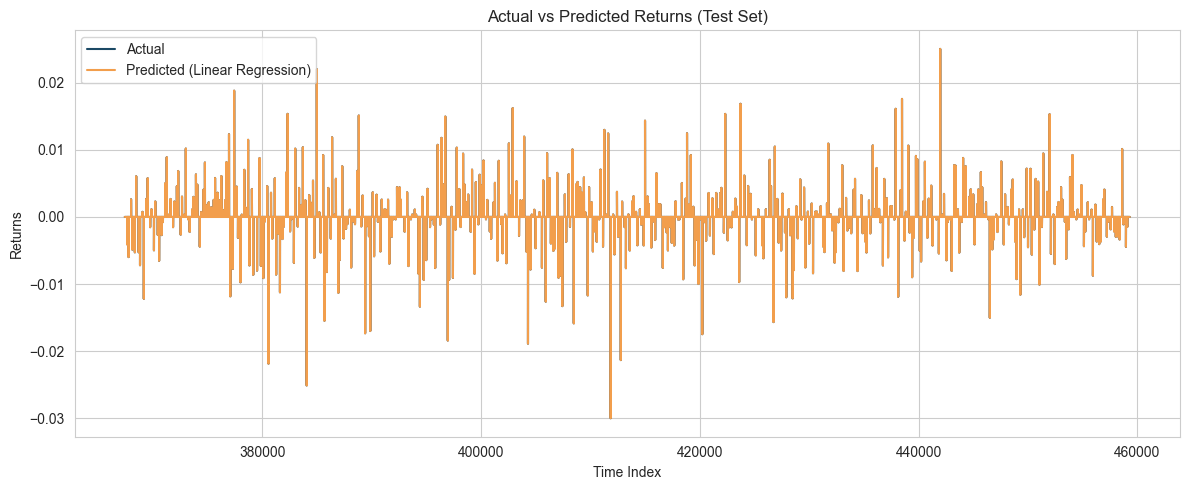

In [12]:
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["model"]

if best_model_name == "Linear Regression":
    y_pred_best = y_pred_linreg
elif best_model_name == "Random Forest":
    y_pred_best = y_pred_rf
elif best_model_name == "XGBoost":
    y_pred_best = y_pred_xgb
else:
    y_pred_best = y_pred_naive

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual", color="#1b4965")
plt.plot(y_test.index, y_pred_best, label=f"Predicted ({best_model_name})", color="#f29e4c")
plt.title("Actual vs Predicted Returns (Test Set)")
plt.xlabel("Time Index")
plt.ylabel("Returns")
plt.legend()
plt.tight_layout()

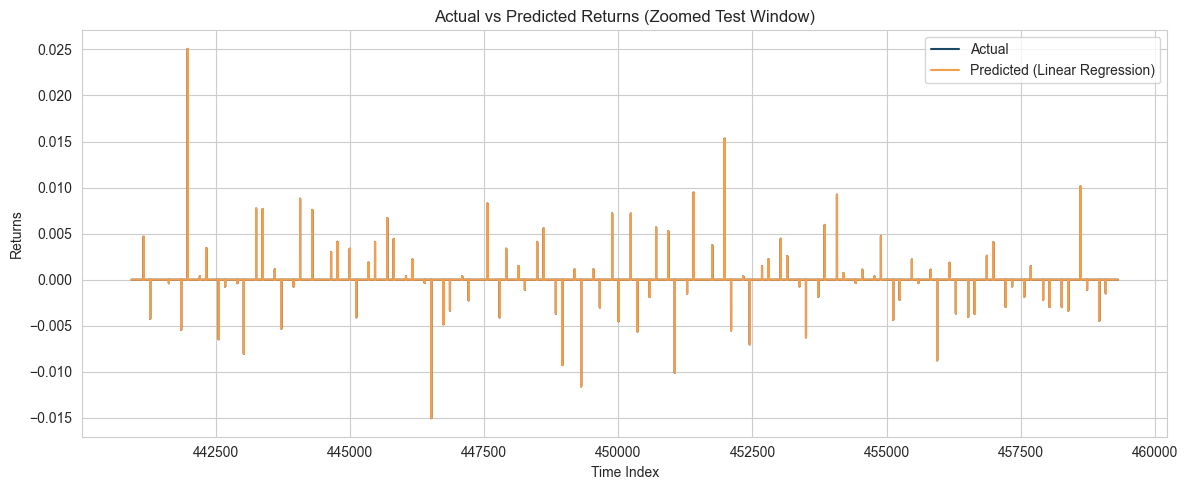

In [13]:
# Zoom on the last 20% of the test period
zoom_size = max(20, int(len(y_test) * 0.2))
zoom_idx = y_test.index[-zoom_size:]

plt.figure(figsize=(12, 5))
plt.plot(zoom_idx, y_test.loc[zoom_idx], label="Actual", color="#1b4965")
plt.plot(zoom_idx, pd.Series(y_pred_best, index=y_test.index).loc[zoom_idx], label=f"Predicted ({best_model_name})", color="#f29e4c")
plt.title("Actual vs Predicted Returns (Zoomed Test Window)")
plt.xlabel("Time Index")
plt.ylabel("Returns")
plt.legend()
plt.tight_layout()

## 10. Model Saving

In [14]:
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save best non-naive model to disk
best_savable = results_df[results_df["object"].notna()].iloc[0]
best_model_object = best_savable["object"]
model_path = MODEL_DIR / "forecast_model.pkl"

joblib.dump(best_model_object, model_path)
print("Saved model:", model_path.resolve())

Saved model: C:\Users\User\Desktop\Ziad\Perso\Projects\AI Financial Forecasting & Assistant\model\forecast_model.pkl


## 11. Key Insights

In [15]:
print("Key Insights")
print("- Best model by RMSE:", results_df.iloc[0]["model"])
print("- Overall predictability: returns can be noisy; performance close to baseline suggests limited signal.")
print("- Limitations: short-term returns are volatile and may be influenced by external factors.")
print("- Improvements: add exogenous variables, tune hyperparameters, and evaluate rolling-window CV.")

Key Insights
- Best model by RMSE: Linear Regression
- Overall predictability: returns can be noisy; performance close to baseline suggests limited signal.
- Limitations: short-term returns are volatile and may be influenced by external factors.
- Improvements: add exogenous variables, tune hyperparameters, and evaluate rolling-window CV.
